# MNIST 0–9 Digit Classification — A Visual Deep Learning Tutorial

**Goal:** Build a neural network that recognizes handwritten digits **0–9**, understand what the model is learning through visualizations, evaluate it carefully, and finally upload your own handwritten digit for prediction.


### What we will visualize

- Random examples from the dataset
- Individual digits as pixel heatmaps
- Class distribution
- Average image for every digit
- The model architecture
- Training/validation loss and accuracy
- Confusion matrix
- Correct vs. incorrect predictions
- Prediction probabilities
- Your own uploaded digit at the end

### Learning path

**Data → Pixels → CNN → Training → Visualizing what was learned → Evaluation → Your own digit**

## 1. Imports and reproducibility

We use **TensorFlow/Keras** for the neural network and Matplotlib/Seaborn for visual explanations.

The model is a small **Convolutional Neural Network (CNN)**. CNNs are especially useful for images because they can learn local patterns such as edges, curves, and parts of handwritten digits.

In [1]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Working directory:", os.getcwd())

TensorFlow version: 2.20.0
Working directory: /content


## 2. Find the dataset inside `sample_data/`

dataset in:

```text
/content/sample_data/
```

The next cell lists the files so you can immediately see what Colab can access.

In [2]:
DATA_DIR = "/content/sample_data"

if not os.path.exists(DATA_DIR):
    print(f"Folder not found: {DATA_DIR}")
    print("Create/upload a folder named 'sample_dataset' in Colab, then run this cell again.")
else:
    files = []
    for root, dirs, filenames in os.walk(DATA_DIR):
        for filename in filenames:
            files.append(os.path.join(root, filename))

    print(f"Found {len(files)} file(s):")
    for f in files[:100]:
        print(" -", f)

    if len(files) > 100:
        print(f"... and {len(files)-100} more")

Found 6 file(s):
 - /content/sample_data/README.md
 - /content/sample_data/anscombe.json
 - /content/sample_data/mnist_test.csv
 - /content/sample_data/california_housing_train.csv
 - /content/sample_data/mnist_train_small.csv
 - /content/sample_data/california_housing_test.csv


## 3. Load MNIST data

This loader supports several common layouts:

1. **CSV** with a `label`/`digit` column and 784 pixel columns
2. CSV where the **first column is the label**
3. **NPZ** containing `x_train`, `y_train`, `x_test`, `y_test`
4. NPY arrays where image and label files are recognizable from their names

If your files use a different structure, inspect the file listing above and adjust the small loader section.

In [3]:
def normalize_images(X):
    X = np.asarray(X)

    # Handle flattened 784-pixel images
    if X.ndim == 2 and X.shape[1] == 784:
        X = X.reshape(-1, 28, 28)

    # Handle images with a single channel
    if X.ndim == 4 and X.shape[-1] == 1:
        X = X[..., 0]

    # Resize-like fallback is intentionally not automatic:
    # this tutorial expects MNIST-style 28x28 images.
    if X.ndim != 3 or X.shape[1:] != (28, 28):
        raise ValueError(
            f"Expected images shaped (N, 28, 28) or (N, 784), got {X.shape}"
        )

    X = X.astype("float32")
    if X.max() > 1:
        X /= 255.0
    return X


def find_column(df, candidates):
    lower = {str(c).strip().lower(): c for c in df.columns}
    for name in candidates:
        if name in lower:
            return lower[name]
    return None


def load_from_csv(path):
    df = pd.read_csv(path)
    label_col = find_column(df, ["label", "digit", "target", "class", "y"])

    # If there is no named label column, assume first column is the label
    # when the remaining columns look like 784 pixels.
    if label_col is None and df.shape[1] == 785:
        label_col = df.columns[0]

    if label_col is None:
        return None

    y = df[label_col].to_numpy()
    X_df = df.drop(columns=[label_col])

    # Remove a common accidental index column.
    if X_df.shape[1] == 785 and str(X_df.columns[0]).lower().startswith("unnamed"):
        X_df = X_df.iloc[:, 1:]

    if X_df.shape[1] != 784:
        return None

    X = X_df.to_numpy()
    return normalize_images(X), y.astype("int64")


# Explicitly load train and test datasets from the available CSV files
# Since `mnist_train_small.csv` and `mnist_test.csv` are present, we'll use them directly.

X_train, y_train = load_from_csv(os.path.join(DATA_DIR, 'mnist_train_small.csv'))
X_test, y_test = load_from_csv(os.path.join(DATA_DIR, 'mnist_test.csv'))

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Pixel range:", X_train.min(), "to", X_train.max())
print("Classes:", np.unique(y_train))


Shapes:
X_train: (19999, 28, 28) y_train: (19999,)
X_test : (9999, 28, 28) y_test : (9999,)
Pixel range: 0.0 to 1.0
Classes: [0 1 2 3 4 5 6 7 8 9]


## 4. First look at the data

A neural network does not see a digit as the character `"7"`.

It sees a **28 × 28 grid of numbers**.

For a grayscale MNIST image:

- `0` ≈ black/background
- `1` ≈ white/ink
- values in between ≈ shades of gray

Let's look at the same digit in two ways: as an image and as a numerical pixel matrix.

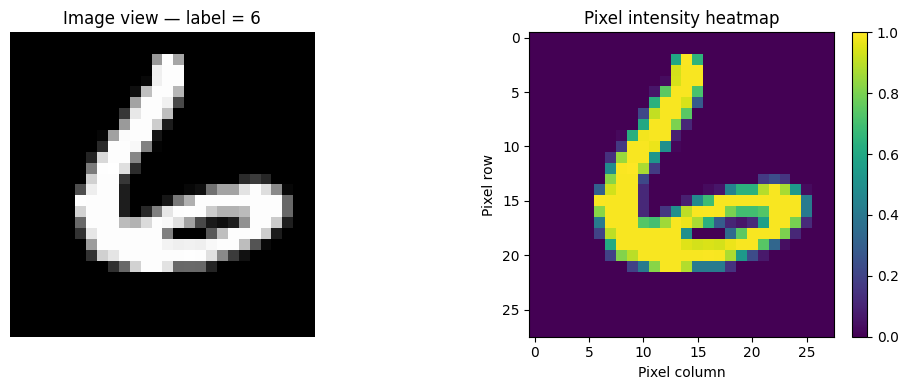

First image as a 28×28 array:
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.6
  1.   0.65 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.94
  0.99 0.99 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.03 0.94
  0.99 0.99 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.06 0.75 0.99
  0.99 0.71 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.64 0.99 0.99
  0.94 0.29 0.   0.   0.   0.   0

In [4]:
idx = 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(X_train[idx], cmap="gray")
axes[0].set_title(f"Image view — label = {y_train[idx]}")
axes[0].axis("off")

im = axes[1].imshow(X_train[idx], cmap="viridis")
axes[1].set_title("Pixel intensity heatmap")
axes[1].set_xlabel("Pixel column")
axes[1].set_ylabel("Pixel row")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("First image as a 28×28 array:")
print(np.round(X_train[idx], 2))

## 6. How many examples do we have for each digit?

A balanced dataset is helpful because we want the model to see roughly comparable amounts of each class.

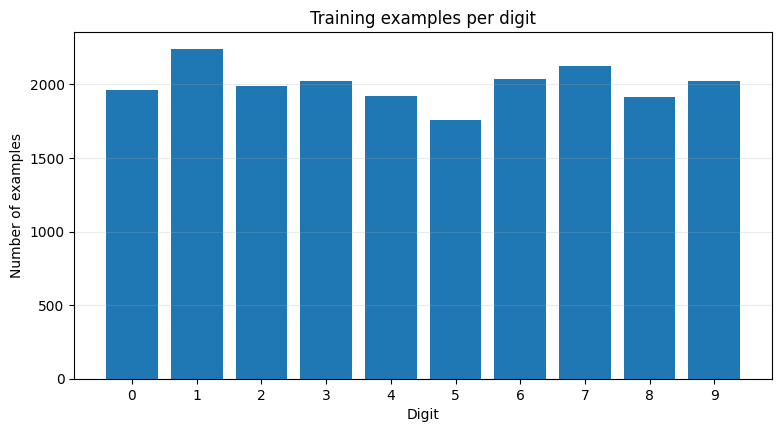

0    1962
1    2243
2    1989
3    2021
4    1924
5    1761
6    2038
7    2126
8    1912
9    2023
Name: count, dtype: int64


In [5]:
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(9, 4.5))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Training examples per digit")
plt.xlabel("Digit")
plt.ylabel("Number of examples")
plt.grid(axis="y", alpha=0.25)
plt.show()

print(class_counts)

# 8. Prepare images for a CNN

A CNN expects images with a channel dimension.

Our data currently has:

```text
(number of images, 28, 28)
```

We add one channel:

```text
(number of images, 28, 28, 1)
```

The final `1` means **grayscale**.

In [6]:
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("CNN input shape:", X_train_cnn.shape)

CNN input shape: (19999, 28, 28, 1)


# 9. Build the CNN

The model will learn in stages:

**Input image → processing layers → dense layers → 10 class probabilities**

In [7]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", name="conv1"),
    layers.MaxPooling2D((2, 2), name="pool1"),

    layers.Conv2D(64, (3, 3), activation="relu", name="conv2"),
    layers.MaxPooling2D((2, 2), name="pool2"),

    layers.Flatten(),
    layers.Dense(128, activation="relu", name="dense1"),
    layers.Dropout(0.30),
    layers.Dense(10, activation="softmax", name="output")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# 11. Train the model

We keep **20% of the training data for validation**.

Validation data is not used to update the weights. It helps us monitor how well the model generalizes to images it did not train on.

In [8]:
history = model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8379 - loss: 0.5414 - val_accuracy: 0.9520 - val_loss: 0.1520
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9561 - loss: 0.1451 - val_accuracy: 0.9707 - val_loss: 0.0944
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9702 - loss: 0.0970 - val_accuracy: 0.9762 - val_loss: 0.0727
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9770 - loss: 0.0746 - val_accuracy: 0.9775 - val_loss: 0.0697
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9809 - loss: 0.0612 - val_accuracy: 0.9797 - val_loss: 0.0634
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9846 - loss: 0.0497 - val_accuracy: 0.9810 - val_loss: 0.0619
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9867 - loss: 0.0424 - val_accuracy: 0.9825 - val_loss: 0.0514
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9872 - loss: 0.0365 - val_accuracy: 0

# 13. Test-set evaluation

The test set is our final unbiased check.

We will look at:

1. Overall accuracy
2. Confusion matrix
3. Per-class precision/recall
4. Individual predictions

In [9]:
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

Test loss:     0.0444
Test accuracy: 98.6099%


# 18. Upload your own handwritten digit

🎉 **This is the interactive part for students.**

### How to prepare your image

For the best results:

- Write **one digit only**
- Use a dark digit on a light background
- Avoid extra marks
- A square image works best
- PNG/JPG are fine
- The notebook will convert it to grayscale and resize it to **28 × 28**

> If your uploaded image has black ink on a white background, the preprocessing cell will automatically invert it when needed so that it resembles the MNIST convention.

Saving Screenshot 2026-08-12 142721.png to Screenshot 2026-08-12 142721.png
Uploaded: Screenshot 2026-08-12 142721.png


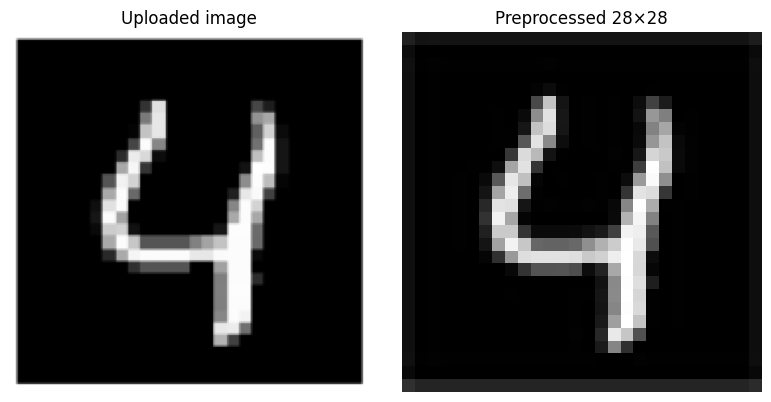

In [10]:
from google.colab import files
from PIL import Image, ImageOps

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file was uploaded.")

uploaded_name = next(iter(uploaded.keys()))
print("Uploaded:", uploaded_name)

img = Image.open(uploaded_name).convert("L")

# Crop surrounding whitespace.
bbox = ImageOps.invert(img).getbbox()
if bbox is not None:
    img = img.crop(bbox)

# Make a square canvas with padding.
side = max(img.size)
canvas = Image.new("L", (side, side), color=0)

left = (side - img.width) // 2
top = (side - img.height) // 2
canvas.paste(img, (left, top))

# Resize to MNIST's 28x28 format.
img28 = canvas.resize((28, 28), Image.Resampling.LANCZOS)

arr = np.asarray(img28).astype("float32") / 255.0

# Invert colors if the image appears to have a white background (high mean pixel value)
# MNIST digits are white on a black background, but some uploads might be black on white.
if arr.mean() > 0.5: # Threshold to determine if background is likely white
    arr = 1.0 - arr
    print("Inverting image colors to match dataset convention (white digit on black background).")

# Show before/after preprocessing.
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(Image.open(uploaded_name).convert("L"), cmap="gray")
axes[0].set_title("Uploaded image")
axes[0].axis("off")

axes[1].imshow(arr, cmap="gray")
axes[1].set_title("Preprocessed 28×28")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 19. Predict your digit

The model now receives your image in exactly the same basic shape as the test data.

We will display:

- The predicted digit
- The model's probability for all 10 digits
- The processed image

Predicted digit: 4
Confidence: 99.98%


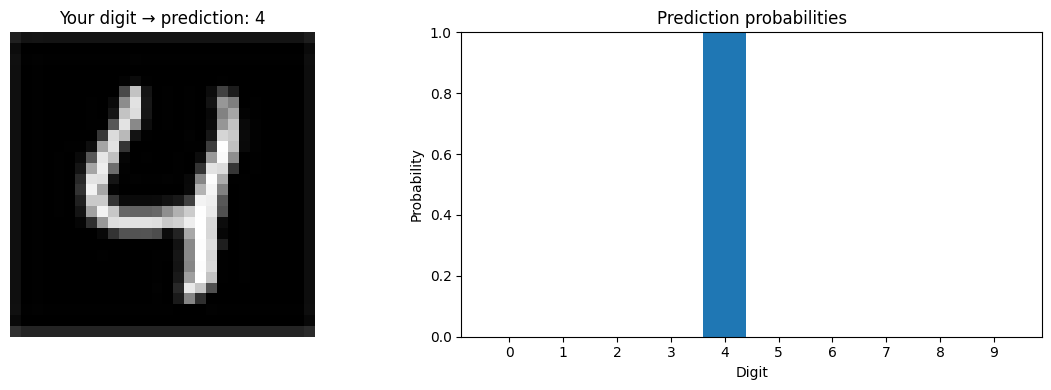

In [11]:
student_image = arr[np.newaxis, ..., np.newaxis]

student_prob = model.predict(student_image, verbose=0)[0]
student_pred = int(np.argmax(student_prob))
student_confidence = float(np.max(student_prob))

print(f"Predicted digit: {student_pred}")
print(f"Confidence: {student_confidence:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(arr, cmap="gray")
axes[0].set_title(f"Your digit → prediction: {student_pred}")
axes[0].axis("off")

axes[1].bar(range(10), student_prob)
axes[1].set_xticks(range(10))
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Probability")
axes[1].set_title("Prediction probabilities")

plt.tight_layout()
plt.show()

# 20. Optional: save the trained model

If you want students to train once and reuse the model later, save it as a Keras model.

The saved file can be downloaded from Colab.

In [12]:
MODEL_PATH = "/content/mnist_digit_cnn.keras"
model.save(MODEL_PATH)

print("Saved:", MODEL_PATH)

# Uncomment in Colab to download:
# from google.colab import files
# files.download(MODEL_PATH)

Saved: /content/mnist_digit_cnn.keras
